In [20]:
import matplotlib.pyplot as plt
import numpy as np
from nskernel import NonStationaryKernel
from scipy.optimize import fmin_l_bfgs_b, curve_fit
from spleaf import cov, term
import scipy.io as sp
import emcee
import pandas as pd

In [ ]:
star_name = "Sun"
data_path = "../nskernel/data/Solar_Data"

In [ ]:
data_rhk = pd.read_csv(f"{data_path}/Analyse_summary.csv")

data_rhk = data_rhk[data_rhk["flag"] != 1]

arr_len = len(data_rhk)
tt = np.array(data_rhk["jdb"])
rhk = np.array(data_rhk["MHK_cleaned"])
rhk_err = np.array(data_rhk["MHK_cleaned_std"])

data_rv = pd.read_pickle(f"{data_path}/Analyse_ccf.p")[f'CCF_kitcat_mask_{star_name}']['matching_instrument']['table']
data_rv = data_rv.loc[data_rv.index.isin(data_rhk.index)]

rv = np.array(data_rv['rv'])
erv = np.sqrt(np.array(data_rv['rv_std'])**2 + (np.ones_like(rv) * 0.0005)**2)


rv_mean = np.mean(rv)
rv_std  = np.std(rv)
rv_norm = (rv - rv_mean) / rv_std

rhk_mean = np.mean(rhk)
rhk_std  = np.std(rhk)
rhk_norm = (rhk - rhk_mean) / rhk_std

# # ERROR normalization using SAME scaling as parent data
erv_norm     = erv / rv_std
rhk_err_norm = rhk_err / rhk_std


T = [tt,tt]
Y = [rv_norm,rhk_norm]
Yerr = [erv_norm,rhk_err_norm]

t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)

plt.plot(tt, rv_norm, ".")


In [22]:
def alpha(t, pcyc, phi, k, c):
    # constraint |k| <= 1/3
    # k = (1.0 / 3.0) * np.tanh(k_raw)
    x = (2.0 * np.pi / pcyc) * t + phi

    fc = np.sin(x + k * np.sin(x))  # in [-1, 1]

    # linear normalization to [C, 1]
    return ((1.0 - c) / 2.0) * (fc + 1.0) + c

def alpha_grad(t, pcyc, phi, k, c):
    
    omega = 2.0 * np.pi / pcyc
    x = omega * t + phi

    # k is provided directly (assumed already constrained to |k| <= 1/3)
    # (previously: k = (1.0 / 3.0) * np.tanh(k_raw))

    inner = x + k * np.sin(x)
    s_inner = np.sin(inner)
    c_inner = np.cos(inner)

    scale = (1.0 - c) / 2.0

    # d(inner)/dx
    d_inner_dx = 1.0 + k * np.cos(x)

    # d alpha / d s
    d_alpha_ds = scale

    # chain: d alpha / d inner
    d_alpha_dinner = d_alpha_ds * c_inner

    grads = {}

    # ----- derivative wrt phi -----
    # dx/dphi = 1
    grads['phi'] = d_alpha_dinner * d_inner_dx

    # ----- derivative wrt pcyc -----
    # omega = 2π/pcyc
    domega_dp = -2.0 * np.pi / (pcyc ** 2)
    dx_dp = domega_dp * t
    grads['pcyc'] = d_alpha_dinner * d_inner_dx * dx_dp

    # ----- derivative wrt k -----
    # k is the input directly, so dk/dk = 1
    d_inner_dk = np.sin(x)
    grads['k'] = d_alpha_dinner * d_inner_dk

    # ----- derivative wrt c -----
    # alpha = scale*(s+1) + c
    # scale = (1-C)/2
    # d alpha / dC = -(1/2)*(s+1) + 1
    grads['c'] = -0.5 * (s_inner + 1.0) + 1.0

    return grads


In [23]:
class MultiSeriesKernel(term.MultiSeriesKernel):
  def _grad_param(self, grad_dU=None, grad_dV=None):
    if grad_dU is not None or grad_dV is not None:
      raise NotImplementedError()
    return super()._grad_param()

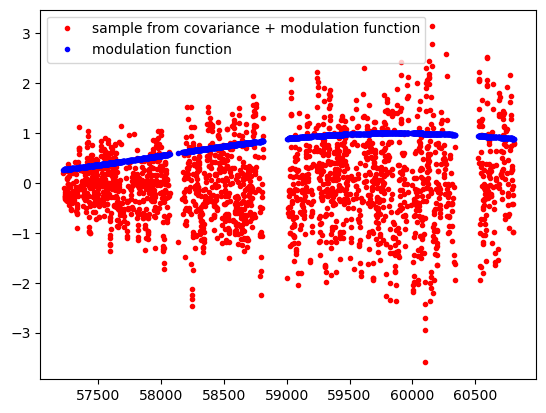

In [24]:
stds = [np.std(y) for y in Y]
sig = np.var(y_full)   
prot = 20.0
Q = 1.0

rvjit = 0.1*stds[0]
rhkjit = 0.1*stds[1]

# a1, a2, c, pcyc = 0.5, -6.1, 2.0, 2500.0

pcyc, phi, k, c = 8000.0, -np.pi/2, 0.1, 0.1

# rho = 4.5
# eta = 1.6

C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  rhk_jit=term.InstrumentJitter(series_index[1], rhkjit),
  gp=term.SimpleProductKernel(
      nonstat=NonStationaryKernel(alpha, alpha_grad, pcyc=pcyc, phi = phi, k = k, c = c),
      rot = MultiSeriesKernel(term.SHOKernel(sig,prot,Q), series_index, 
        np.ones(2) * stds, 
        np.array([stds[0], 0.0])
    ),
  )
)
          

fc_norm = alpha(t_full[series_index[0]], pcyc, phi, k, c)
drawn_sample = C.sample()[series_index[0]]

plt.plot(t_full[series_index[0]], drawn_sample, ".", color="red", label="sample from covariance + modulation function")
plt.plot(t_full[series_index[0]], fc_norm, ".", color="blue", label="modulation function")
plt.legend()


In [25]:
rvjit_max = 5*stds[0]
rhkjit_max = 5*stds[1]

prot_min = 17.0
prot_max = 30.0
Q_min = 0.7
Q_max = 1.7

pcyc_min = 7000.0
pcyc_max = 9000.0


# eta_min = 0.4
# eta_max = 2.9
# rho_min = 2.8
# rho_max = 6.2

alpha_0_max = 5*stds[0]
alpha_1_max = 5*stds[1]
beta_0_max  = 5*stds[0]
beta_1_max  = 5*stds[1]
gamma_0_max = 5*stds[0]
gamma_1_max = 5*stds[1]

bounds_list = [
    (0.0, rvjit_max),                     # rv_jit.sig
    (0.0, rhkjit_max),                     # rhk_jit.sig
    (pcyc_min, pcyc_max),  
    (0,np.pi*2), # phi
    (-0.4,0.4),
    (0.01,0.9),
    # (-10,10),
    
    (prot_min, prot_max),                 # rot.P0 (period)
    (Q_min, Q_max),                      # rot.Q (quality factor)
    # (rho_min, rho_max),                   # rot.rho 
    # (eta_min, eta_max),                   # rot.eta
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-beta_0_max, beta_0_max),         # rot.beta_0      
    (0.6, gamma_0_max*2+2),         # rot.gamma_0
    (0.6, gamma_1_max*2+2),         # rot.gamma_1
    (-gamma_0_max, gamma_0_max),         # delta_0 (offset for series 0)
    (-gamma_1_max, gamma_1_max),         # delta_1 (offset for series 1)
]

C.param

['rv_jit.sig',
 'rhk_jit.sig',
 'gp.nonstat_pcyc',
 'gp.nonstat_phi',
 'gp.nonstat_k',
 'gp.nonstat_c',
 'gp.rot_sig',
 'gp.rot_P0',
 'gp.rot_Q',
 'gp.rot_alpha_0',
 'gp.rot_alpha_1',
 'gp.rot_beta_0',
 'gp.rot_beta_1']

In [26]:
fitted = [k for k, key in enumerate(C.param) if key != 'gp.rot_sig' and key != "gp.rot_beta_1"]  
params = [C.param[k] for k in fitted]
x0 = C.get_param(params)

x0 = np.append(x0,[0.0,0.0,0.0,0.0])

def negloglike(x, y, C):
  
  C.set_param(x[:len(params)], params)
  fc = alpha(t_full, x[2],x[3],x[4],x[5])
  fc_unnorm = (fc - x[5]) / ((1.0 - x[5]) / 2.0) - 1
  y_model = y.copy()
  y_model[series_index[0]] -= (x[-4]*fc_unnorm[series_index[0]] + x[-2])
  y_model[series_index[1]] -= (x[-3]*fc_unnorm[series_index[1]] + x[-1])
  nll = -C.loglike(y_model)
  # gradient
  lg = C.loglike_grad()
  dL_dy = np.asarray(lg[0]).reshape(-1)      # shape (N_total,) 
  dL_dparams = np.asarray(lg[1]).reshape(-1) # shape (12,)      

  base_grad = - dL_dparams[fitted]  

  # gradients wrt gamma (scale of fc)
  grad_gamma_0 = np.sum(dL_dy[series_index[0]] * fc_unnorm[series_index[0]])
  grad_gamma_1 = np.sum(dL_dy[series_index[1]] * fc_unnorm[series_index[1]])
  # gradients wrt delta (additive offsets)
  grad_delta_0 = np.sum(dL_dy[series_index[0]])
  grad_delta_1 = np.sum(dL_dy[series_index[1]])

  nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_gamma_0, grad_gamma_1, grad_delta_0, grad_delta_1])])


  # nll_grad = -C.loglike_grad()[1][fitted]

  return (nll, nll_grad)


result = fmin_l_bfgs_b(negloglike, x0, args=(y_full, C), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)
C.set_param([0.0], ['gp.rot_beta_1'])


print(params)
print(xbest)

['rv_jit.sig', 'rhk_jit.sig', 'gp.nonstat_pcyc', 'gp.nonstat_phi', 'gp.nonstat_k', 'gp.nonstat_c', 'gp.rot_P0', 'gp.rot_Q', 'gp.rot_alpha_0', 'gp.rot_alpha_1', 'gp.rot_beta_0']
[ 2.87605244e-01  0.00000000e+00  7.99822402e+03  8.07144220e-03
  4.00000000e-01  9.00000000e-01  3.00000000e+01  7.00000000e-01
  1.02797490e+00  1.08537915e+00  8.65747826e-01  6.00000000e-01
  6.00000000e-01 -1.81442288e-01 -1.76934746e-01]


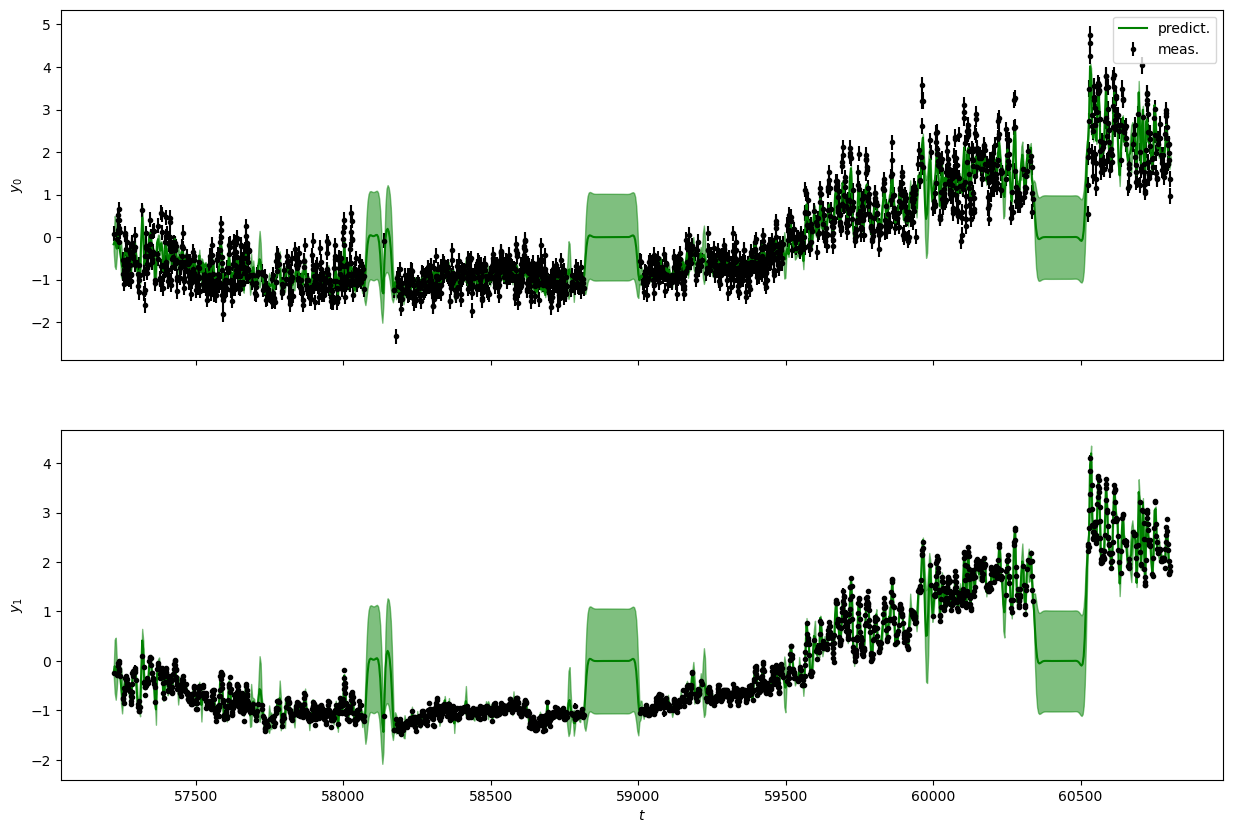

In [27]:
# C.set_param([0.0], ['gp.beta_0'])  
# C.set_param(xbest)

# C.set_param(samples[-1,0,:], params)

tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['gp'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  fc = alpha(t_full, xbest[2],xbest[3],xbest[4],xbest[5])
  fc_unnorm = (fc - xbest[5]) / ((1.0 - xbest[5]) / 2.0) - 1
  y_model = y_full.copy()
  y_model[series_index[0]] -= (xbest[-4]*fc_unnorm[series_index[0]] + xbest[-2])
  y_model[series_index[1]] -= (xbest[-3]*fc_unnorm[series_index[1]] + xbest[-1])

  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(xbest[-4]*fc_unnorm[series_index[0]]+xbest[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(xbest[-3]*fc_unnorm[series_index[1]]+xbest[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

In [28]:
def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    # rv_jit, rhk_jit, pcyc, phi, k_raw, c, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    rv_jit, rhk_jit, pcyc, phi, k, c, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    phi = phi % (2*np.pi)
    if 0.0 < rv_jit < rvjit_max and 0.0 < rhk_jit < rhkjit_max and pcyc_min < pcyc < pcyc_max and 0 < phi < np.pi*2 and -0.4< k < 0.4 and 0.01 < c < 0.9 and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and 0.0 < gamma_0 < gamma_0_max and 0.0 < gamma_1 < gamma_0_max and -gamma_0_max < delta_0 < gamma_0_max and -gamma_0_max < delta_1 < gamma_0_max:
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = xbest.copy()
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 2000, progress=True);



[ 2.87605244e-01  0.00000000e+00  7.99822402e+03  8.07144220e-03
  4.00000000e-01  9.00000000e-01  3.00000000e+01  7.00000000e-01
  1.02797490e+00  1.08537915e+00  8.65747826e-01  6.00000000e-01
  6.00000000e-01 -1.81442288e-01 -1.76934746e-01]
-inf


  0%|          | 0/2000 [00:00<?, ?it/s]/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [05:32<00:00,  6.01it/s]


['rv_jit.sig', 'rhk_jit.sig', 'gp.nonstat_pcyc', 'gp.nonstat_phi', 'gp.nonstat_k', 'gp.nonstat_c', 'gp.rot_P0', 'gp.rot_Q', 'gp.rot_alpha_0', 'gp.rot_alpha_1', 'gp.rot_beta_0', 'gamma_0', 'gamma_1', 'delta_0', 'delta_1']


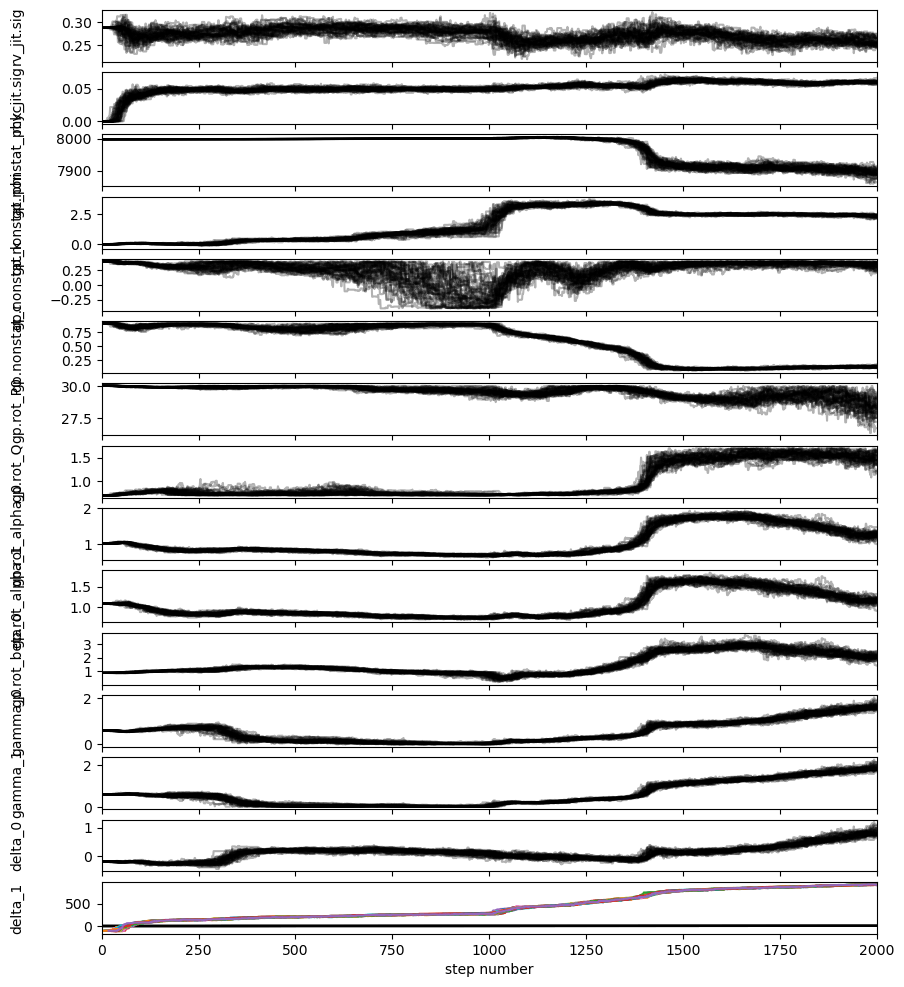

In [29]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 4, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()

# labels = params + ['gamma_0', 'gamma_1', 'delta_0', 'delta_1']
labels = params + ['gamma_0', 'gamma_1', 'delta_0', 'delta_1']
print(labels)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

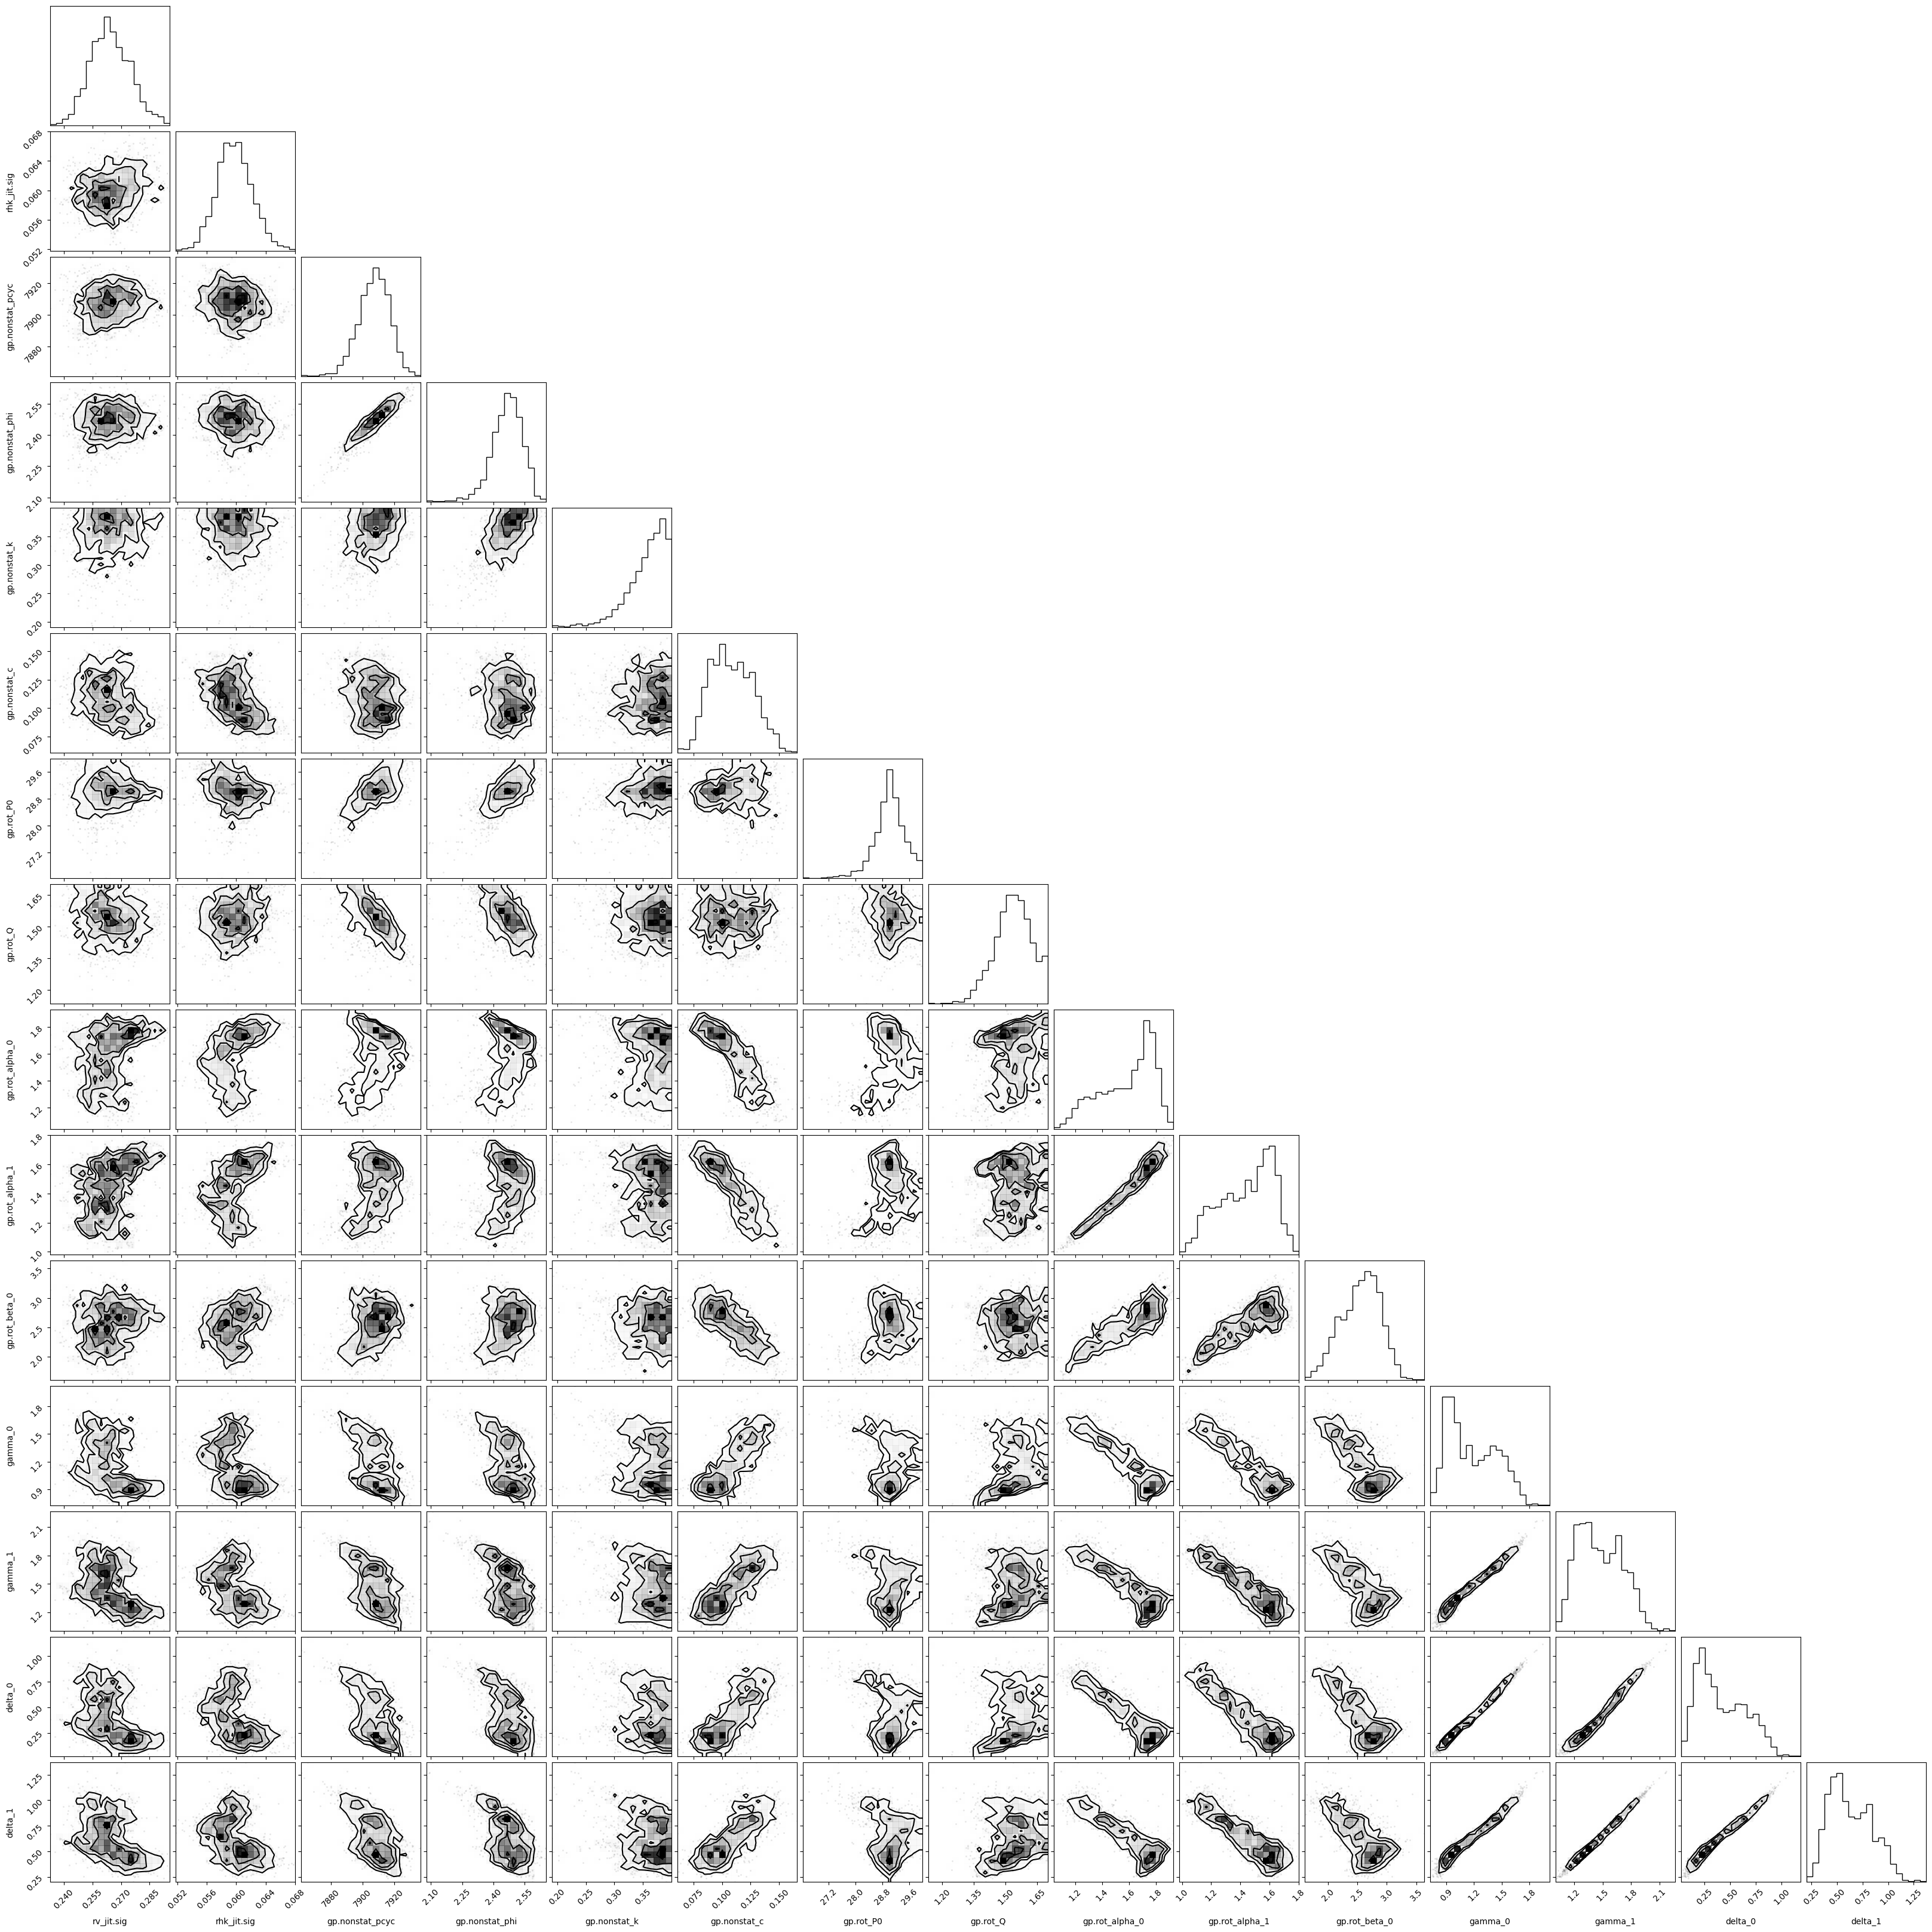

In [30]:
import corner

flat_samples = sampler.get_chain(discard=1500, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);



In [ ]:
burn = 1500   
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

# np.save("sun_map_sample.npy", map_sample)

MAP index (in flattened, post-burn chain): 22058
MAP log-posterior: 935.5523790425987
MAP sample (theta): [2.48268991e-01 5.89027021e-02 7.88475534e+03 2.26145548e+00
 2.85734754e-01 1.25389583e-01 2.79284266e+01 1.45004397e+00
 1.37047924e+00 1.19675458e+00 2.14374935e+00 1.65114642e+00
 1.93500855e+00 8.60060688e-01 1.07228574e+00]


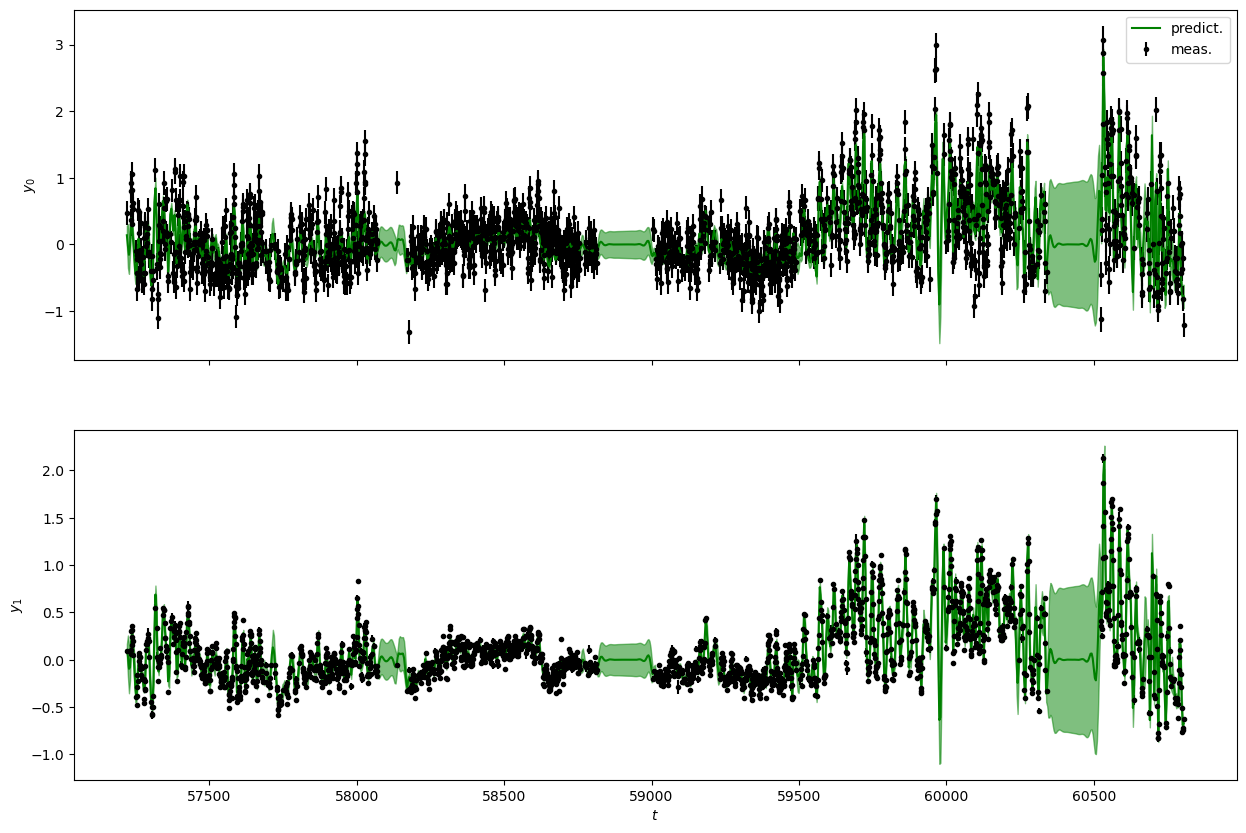

In [33]:
C.set_param(map_sample[:len(params)], params)
C.set_param([0.0], ['gp.rot_beta_1'])
C.set_param([np.var(y_full)], ['gp.rot_sig'])


tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10))


for k in range(2):
  # Predict time series k
  C.kernel['gp'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)
  # use MAP sample for modulation and offsets
  fc = alpha(t_full, map_sample[2], map_sample[3], map_sample[4],map_sample[5])
  fc_unnorm = (fc - map_sample[5]) / ((1.0 - map_sample[5]) / 2.0) - 1
  y_model = y_full.copy()
  # map_sample tail: [..., gamma_0, gamma_1, delta_0, delta_1]
  y_model[series_index[0]] -= map_sample[-4]*fc_unnorm[series_index[0]] + map_sample[-2]
  y_model[series_index[1]] -= map_sample[-3]*fc_unnorm[series_index[1]] + map_sample[-1]
  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = Y[k] - mu_res
  else:
    res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(map_sample[-4]*fc_unnorm[series_index[0]]+map_sample[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(map_sample[-3]*fc_unnorm[series_index[1]]+map_sample[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

In [ ]:
fc = alpha(t_full[series_index[0]], map_sample[2],map_sample[3],map_sample[4],map_sample[5])
plt.figure()
plt.plot(t_full[series_index[0]],fc, ".", color="red", label="fitted modulation function")
plt.figure()
plt.plot(t_full[series_index[0]],y_full[series_index[0]],".",color="black")
print(map_sample[-4],map_sample[-3])